In [126]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [ ]:
R_visual = pd.read_csv('../Data/Processed/sales_clean.csv')

R_visual['date'] = pd.to_datetime(R_visual['date'])  
R_visual['months'] = R_visual['date'].dt.to_period('M')  
R_visual

,transaction_id,date,store,category,unit_price,quantity,customer_age,payment_method,returns,months
0,TXN109445,2023-08-27,Store_D_Kano,Groceries,3320.91,4,69.0,transfer,Sales,2023-08
1,TXN123657,2024-08-14,Store_D_Kano,Groceries,2649.43,8,29.0,card,Sales,2024-08
2,TXN106755,2023-06-20,Store_E_Ibadan,Electronics,46741.91,2,41.0,cash,Sales,2023-06
3,TXN128164,2024-12-01,Store_E_Ibadan,Apparel,16237.05,7,42.0,transfer,Sales,2024-12
4,TXN110190,2023-09-16,Store_B_Abuja,Groceries,3310.92,6,58.0,cash,Sales,2023-09
...,...,...,...,...,...,...,...,...,...,...
25830,TXN108527,2023-08-04,Store_C_PortHarcourt,Home_Goods,11313.00,14,43.0,transfer,Sales,2023-08
25831,TXN104714,2023-04-29,Store_B_Abuja,Groceries,3262.61,12,40.0,card,Sales,2023-04
25832,TXN110196,2023-09-16,Store_C_PortHarcourt,Apparel,11276.30,5,25.0,card,Sales,2023-09
25833,TXN108419,2023-08-01,Store_C_PortHarcourt,Electronics,48366.32,4,44.0,card,Sales,2023-08


In [128]:
R_visual['monthly_revenue'] = R_visual['unit_price'] * R_visual['quantity']
R_visual['monthly_revenue']

0         13283.64
1         21195.44
2         93483.82
3        113659.35
4         19865.52
           ...    
25830    158382.00
25831     39151.32
25832     56381.50
25833    193465.28
25834     16105.18
Name: monthly_revenue, Length: 25835, dtype: float64

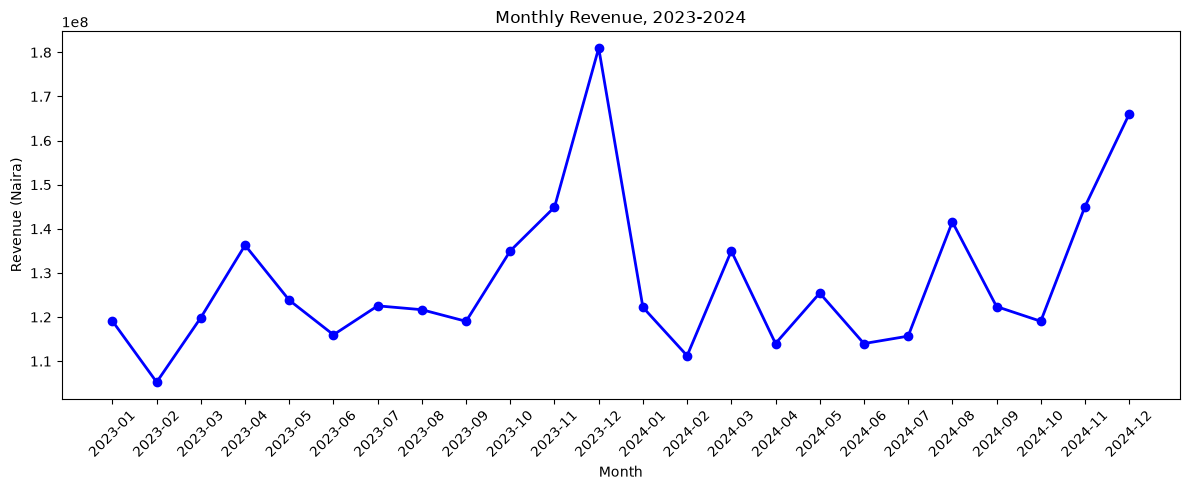

In [129]:

monthly = R_visual.groupby(R_visual['months'])['monthly_revenue'].sum()

plt.figure(figsize=(12, 5))
plt.plot(monthly.index.astype(str), monthly.values, color='blue', marker='o', linewidth=2)
plt.title("Monthly Revenue, 2023-2024")
plt.xlabel("Month")
plt.ylabel("Revenue (Naira)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Revenue across 2023–2024 fluctuates with clear seasonal swings rather than a steady trend. Averaging across both years by calendar month, **December is the strongest month** (₦346.97M average) and **February is the weakest** (₦216.48M average) — a gap of roughly 60%.

Looking at month-over-month % change confirms this pattern in both years individually:
- **December** saw strong growth each year: **+24.89%** (Dec 2023) and **+14.46%** (Dec 2024).
- **February** saw declines both years: **-11.62%** (Feb 2023) and **-8.98%** (Feb 2024).

The other clear outlier is **January 2024**, which dropped **-32.47%** from December 2023 — the single sharpest month-over-month decline in the dataset. This is consistent with a post-December pullback in spending rather than a data quality issue, since Feb 2024 continued the seasonal dip before recovering in March (+21.35%) both years.

**Takeaway**: revenue is seasonal, peaking around the December holiday period and bottoming out in the following January–February window. Inventory, staffing, and marketing spend should be planned accordingly — ramping up ahead of Q4 and expecting a natural slowdown in Q1.

In [130]:
R_visual

,transaction_id,date,store,category,unit_price,quantity,customer_age,payment_method,returns,months,monthly_revenue
0,TXN109445,2023-08-27,Store_D_Kano,Groceries,3320.91,4,69.0,transfer,Sales,2023-08,13283.64
1,TXN123657,2024-08-14,Store_D_Kano,Groceries,2649.43,8,29.0,card,Sales,2024-08,21195.44
2,TXN106755,2023-06-20,Store_E_Ibadan,Electronics,46741.91,2,41.0,cash,Sales,2023-06,93483.82
3,TXN128164,2024-12-01,Store_E_Ibadan,Apparel,16237.05,7,42.0,transfer,Sales,2024-12,113659.35
4,TXN110190,2023-09-16,Store_B_Abuja,Groceries,3310.92,6,58.0,cash,Sales,2023-09,19865.52
...,...,...,...,...,...,...,...,...,...,...,...
25830,TXN108527,2023-08-04,Store_C_PortHarcourt,Home_Goods,11313.00,14,43.0,transfer,Sales,2023-08,158382.00
25831,TXN104714,2023-04-29,Store_B_Abuja,Groceries,3262.61,12,40.0,card,Sales,2023-04,39151.32
25832,TXN110196,2023-09-16,Store_C_PortHarcourt,Apparel,11276.30,5,25.0,card,Sales,2023-09,56381.50
25833,TXN108419,2023-08-01,Store_C_PortHarcourt,Electronics,48366.32,4,44.0,card,Sales,2023-08,193465.28


       store_name  total_revenue
1         B_Abuja    639374092.0
2  C_PortHarcourt    622368028.0
0         A_Lagos    608675625.0
4        E_Ibadan    604186609.0
3          D_Kano    601292281.0


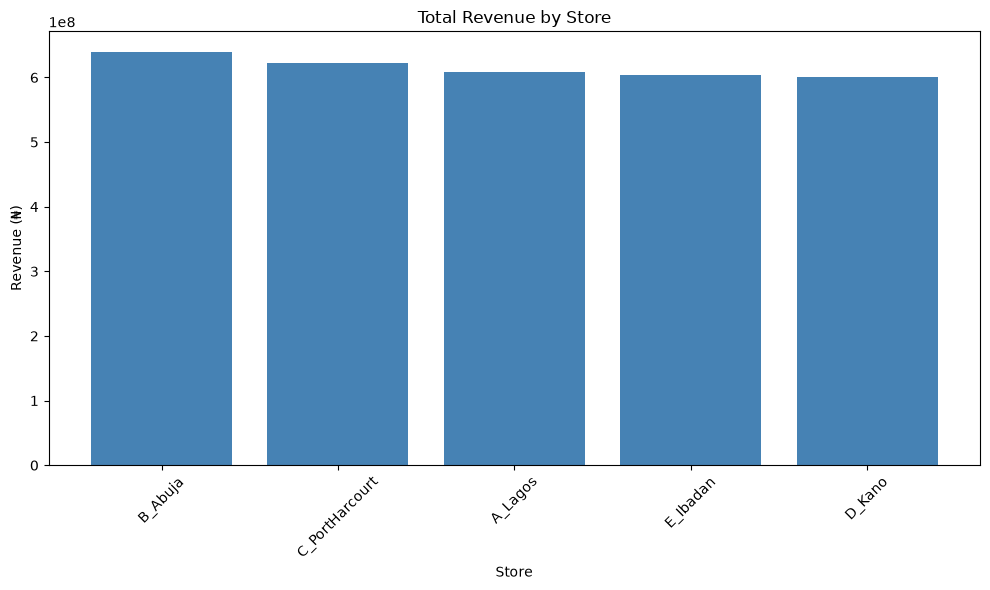

In [147]:
# Store-level revenue summary (replaces cells 6-13)
R_visual['store_name'] = R_visual['store'].str.extract(r'_(.+)$')[0]

store_revenue = (
    R_visual.groupby('store_name')['monthly_revenue']
    .sum()
    .round()
    .reset_index(name='total_revenue')
    .sort_values('total_revenue', ascending=False)
)
print(store_revenue)

plt.figure(figsize=(10, 6))
plt.bar(store_revenue['store_name'], store_revenue['total_revenue'], color='steelblue')
plt.title("Total Revenue by Store")
plt.xlabel("Store")
plt.ylabel("Revenue (₦)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [158]:
# Month-over-month % change (backs up the Dec/Feb claim)
monthly_pct_change = monthly.pct_change().mul(100).round(2)
print(monthly_pct_change)
print()

# Average revenue by calendar month across both years (removes single-year noise)
R_visual['month_num'] = R_visual['date'].dt.month
avg_by_month = R_visual.groupby('month_num')['monthly_revenue'].sum().groupby(level=0).mean()
print(avg_by_month.sort_values(ascending=False))

months
2023-01      NaN
2023-02   -11.62
2023-03    13.90
2023-04    13.69
2023-05    -9.15
2023-06    -6.33
2023-07     5.66
2023-08    -0.72
2023-09    -2.16
2023-10    13.42
2023-11     7.33
2023-12    24.89
2024-01   -32.47
2024-02    -8.98
2024-03    21.35
2024-04   -15.54
2024-05    10.02
2024-06    -9.12
2024-07     1.48
2024-08    22.39
2024-09   -13.56
2024-10    -2.72
2024-11    21.83
2024-12    14.46
Freq: M, Name: monthly_revenue, dtype: float64

month_num
12    3.469690e+08
11    2.899349e+08
8     2.632289e+08
3     2.548515e+08
10    2.540493e+08
4     2.502816e+08
5     2.492366e+08
9     2.414083e+08
1     2.412898e+08
7     2.382096e+08
6     2.299621e+08
2     2.164752e+08
Name: monthly_revenue, dtype: float64


In [149]:
R_visual.groupby(['store', 'category',])['monthly_revenue'].agg(['sum', 'mean', 'count']).reset_index()

,store,category,sum,mean,count
0,Store_A_Lagos,Apparel,6.763128e+07,64967.608626,1041
1,Store_A_Lagos,Beauty,4.023367e+07,38028.047873,1058
2,Store_A_Lagos,Electronics,3.756152e+08,376367.886473,998
3,Store_A_Lagos,Groceries,2.168111e+07,20707.839112,1047
4,Store_A_Lagos,Home_Goods,1.035144e+08,100304.662422,1032
5,Store_B_Abuja,Apparel,6.666609e+07,65940.746469,1011
6,Store_B_Abuja,Beauty,3.899400e+07,37566.475742,1038
7,Store_B_Abuja,Electronics,4.048896e+08,378048.218058,1071
8,Store_B_Abuja,Groceries,2.091791e+07,20690.317676,1011
9,Store_B_Abuja,Home_Goods,1.079064e+08,96431.137221,1119


In [150]:
Abuja_store=R_visual['store'].str.contains('_Abuja')
abuja_quantity = R_visual.loc[Abuja_store, 'quantity'].sum().round()
print(abuja_quantity)



38239


In [151]:
Store_quantity = R_visual.groupby(['store','category'])[['quantity', 'monthly_revenue']].sum()
print(Store_quantity)

                                  quantity  monthly_revenue
store                category                              
Store_A_Lagos        Apparel          7412     6.763128e+07
                     Beauty           7813     4.023367e+07
                     Electronics      7434     3.756152e+08
                     Groceries        7586     2.168111e+07
                     Home_Goods       7635     1.035144e+08
Store_B_Abuja        Apparel          7360     6.666609e+07
                     Beauty           7590     3.899400e+07
                     Electronics      7911     4.048896e+08
                     Groceries        7403     2.091791e+07
                     Home_Goods       7975     1.079064e+08
Store_C_PortHarcourt Apparel          7254     6.581260e+07
                     Beauty           7319     3.734532e+07
                     Electronics      7710     3.952668e+08
                     Groceries        7049     1.994923e+07
                     Home_Goods       76

From the data provided above, it can be seen that Electronics goods generate the most revenue across all stores in each stores by selling over 7000 units.There for, the stores should invest in Electronics in order to increase the number of units sold and also, to increase revenue/profits

In [152]:
def flag_outliers(group):
    q1 = group.quantile(0.25)
    q3 = group.quantile(0.75)
    iqr = q3 - q1
    upper_bound = q3 + 3 * iqr   
    return group > upper_bound

R_visual['price_outlier'] = R_visual.groupby('category')['unit_price'].transform(flag_outliers)

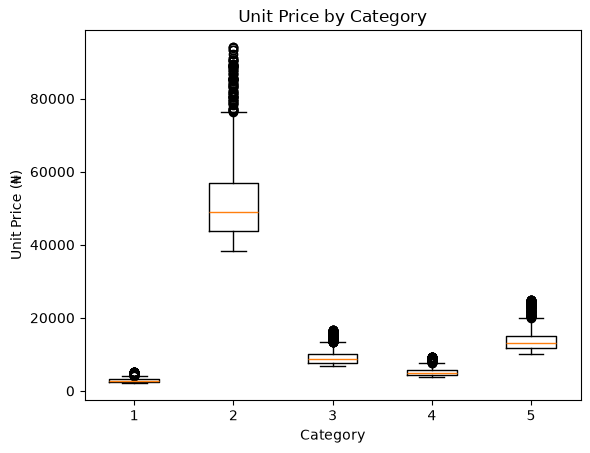

In [153]:
categories = R_visual['category'].unique()
data_by_category = [R_visual[R_visual['category'] == cat]['unit_price'] for cat in categories]

plt.boxplot(data_by_category, label=categories)
plt.title("Unit Price by Category")
plt.xlabel("Category")
plt.ylabel("Unit Price (₦)")
plt.show()

In [156]:
# Outlier counts and percentage per category
outlier_counts = (
    R_visual.groupby('category')['price_outlier']
    .agg(total='count', outliers='sum')
    .assign(outlier_pct=lambda d: (d['outliers'] / d['total'] * 100).round(2))
    .sort_values('outlier_pct', ascending=False)
)
print(outlier_counts)
print()

# Revenue contribution from outlier vs non-outlier transactions
revenue_by_outlier = (
    R_visual.groupby('price_outlier')['monthly_revenue']
    .agg(['sum', 'mean', 'count'])
    .round(2)
)
print(revenue_by_outlier)
print()

# Do outliers correlate with returns?
if R_visual['returns'].nunique() > 1:
    returns_by_outlier = pd.crosstab(
        R_visual['price_outlier'], R_visual['returns'], normalize='index'
    ) * 100
    print(returns_by_outlier.round(2))
else:
    print("returns column has only one unique value:", R_visual['returns'].unique())

             total  outliers  outlier_pct
category                                 
Apparel       5076         0          0.0
Beauty        5241         0          0.0
Electronics   5162         0          0.0
Groceries     5036         0          0.0
Home_Goods    5320         0          0.0

                        sum       mean  count
price_outlier                                
False          3.075897e+09  119059.29  25835

returns        Return  Sales
price_outlier               
False            1.57  98.43


In [157]:
# Re-check with a more standard 1.5x IQR threshold (3x IQR found none)
def flag_outliers_1_5(group):
    q1 = group.quantile(0.25)
    q3 = group.quantile(0.75)
    iqr = q3 - q1
    upper_bound = q3 + 1.5 * iqr
    return group > upper_bound

R_visual['price_outlier_1_5'] = R_visual.groupby('category')['unit_price'].transform(flag_outliers_1_5)

outlier_counts_15 = (
    R_visual.groupby('category')['price_outlier_1_5']
    .agg(total='count', outliers='sum')
    .assign(outlier_pct=lambda d: (d['outliers'] / d['total'] * 100).round(2))
    .sort_values('outlier_pct', ascending=False)
)
print(outlier_counts_15)
print()

# Revenue contribution from outlier vs non-outlier transactions (1.5x IQR)
revenue_by_outlier_15 = (
    R_visual.groupby('price_outlier_1_5')['monthly_revenue']
    .agg(['sum', 'mean', 'count'])
    .round(2)
)
print(revenue_by_outlier_15)
print()

# Do these outliers correlate with returns?
if R_visual['price_outlier_1_5'].sum() > 0:
    returns_by_outlier_15 = pd.crosstab(
        R_visual['price_outlier_1_5'], R_visual['returns'], normalize='index'
    ) * 100
    print(returns_by_outlier_15.round(2))
else:
    print("Still no outliers found even at 1.5x IQR.")

             total  outliers  outlier_pct
category                                 
Apparel       5076       121         2.38
Groceries     5036       101         2.01
Beauty        5241       104         1.98
Home_Goods    5320       104         1.95
Electronics   5162        88         1.70

                            sum       mean  count
price_outlier_1_5                                
False              2.980617e+09  117731.84  25317
True               9.527966e+07  183937.57    518

returns            Return  Sales
price_outlier_1_5               
False                1.55  98.45
True                 2.70  97.30


In [155]:
R_visual.head(30)

,transaction_id,date,store,category,unit_price,quantity,customer_age,payment_method,returns,months,monthly_revenue,price_outlier,store_name
0,TXN109445,2023-08-27,Store_D_Kano,Groceries,3320.91,4,69.0,transfer,Sales,2023-08,13283.64,False,D_Kano
1,TXN123657,2024-08-14,Store_D_Kano,Groceries,2649.43,8,29.0,card,Sales,2024-08,21195.44,False,D_Kano
2,TXN106755,2023-06-20,Store_E_Ibadan,Electronics,46741.91,2,41.0,cash,Sales,2023-06,93483.82,False,E_Ibadan
3,TXN128164,2024-12-01,Store_E_Ibadan,Apparel,16237.05,7,42.0,transfer,Sales,2024-12,113659.35,False,E_Ibadan
4,TXN110190,2023-09-16,Store_B_Abuja,Groceries,3310.92,6,58.0,cash,Sales,2023-09,19865.52,False,B_Abuja
5,TXN119268,2024-04-26,Store_D_Kano,Groceries,2348.88,13,24.0,transfer,Sales,2024-04,30535.44,False,D_Kano
6,TXN110508,2023-09-24,Store_C_PortHarcourt,Electronics,55504.50,5,62.0,transfer,Sales,2023-09,277522.50,False,C_PortHarcourt
7,TXN119332,2024-04-28,Store_A_Lagos,Beauty,5232.20,2,42.0,card,Sales,2024-04,10464.40,False,A_Lagos
8,TXN128041,2024-11-28,Store_E_Ibadan,Apparel,9401.28,12,23.0,card,Sales,2024-11,112815.36,False,E_Ibadan
9,TXN106713,2023-06-19,Store_D_Kano,Groceries,2782.01,6,19.0,cash,Sales,2023-06,16692.06,False,D_Kano
